In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('gemini-advanced.csv')
df.head()

,sequence,complexity,single_formula,eval_single_formula,single_formula_type,single_python,eval_single_script,single_python_type,multiple_python,python_1,eval_python_1,python_1_type,multiple_formula,formula_1,eval_formula_1,formula_1_type
0,"2, 4, 6, 8, 10, 12, 14, 16, 18, 20",1,2n,"2, 4, 6, 8, 10, 12, 14, 16, 18, 20",Pure math,2n,"2, 4, 6, 8, 10, 12, 14, 16, 18, 20",Pure math,2n,2n,"2, 4, 6, 8, 10, 12, 14, 16, 18, 20",Pure math,2n,2n,"2, 4, 6, 8, 10, 12, 14, 16, 18, 20",Pure math
1,"3, 6, 9, 12, 15, 18, 21, 24, 27, 30",1,3n,"3, 6, 9, 12, 15, 18, 21, 24, 27, 30",Pure math,3n,"3, 6, 9, 12, 15, 18, 21, 24, 27, 30",Pure math,3n,3n,"3, 6, 9, 12, 15, 18, 21, 24, 27, 30",Pure math,3n,3n,"3, 6, 9, 12, 15, 18, 21, 24, 27, 30",Pure math
2,"4, 8, 12, 16, 20, 24, 28, 32, 36, 40",1,4n,"4, 8, 12, 16, 20, 24, 28, 32, 36, 40",Pure math,4n,"4, 8, 12, 16, 20, 24, 28, 32, 36, 40",Pure math,4n,4n,"4, 8, 12, 16, 20, 24, 28, 32, 36, 40",Pure math,4n,4n,"4, 8, 12, 16, 20, 24, 28, 32, 36, 40",Pure math
3,"5, 10, 15, 20, 25, 30, 35, 40, 45, 50",1,5n,"5, 10, 15, 20, 25, 30, 35, 40, 45, 50",Pure math,5n,"5, 10, 15, 20, 25, 30, 35, 40, 45, 50",Pure math,5n,5n,"5, 10, 15, 20, 25, 30, 35, 40, 45, 50",Pure math,5n,5n,"5, 10, 15, 20, 25, 30, 35, 40, 45, 50",Pure math
4,"6, 12, 18, 24, 30, 36, 42, 48, 54, 60",1,6n,"6, 12, 18, 24, 30, 36, 42, 48, 54, 60",Pure math,6n,"6, 12, 18, 24, 30, 36, 42, 48, 54, 60",Pure math,6n,6n,"6, 12, 18, 24, 30, 36, 42, 48, 54, 60",Pure math,6n,6n,"6, 12, 18, 24, 30, 36, 42, 48, 54, 60",Pure math


In [3]:
columns = df.columns
print(columns)

Index(['sequence', 'complexity', 'single_formula', 'eval_single_formula',
       'single_formula_type', 'single_python', 'eval_single_script',
       'single_python_type', 'multiple_python', 'python_1', 'eval_python_1',
       'python_1_type', 'multiple_formula', 'formula_1', 'eval_formula_1',
       'formula_1_type'],
      dtype='object')


### Equivalence


Equivalence Results by Complexity Level:
----------------------------------------
         | Complexity 1 | Complexity 2 | Complexity 3
----------------------------------------
Scripts  |    100.0    |    40.0     |     0.0    
Formulae |    100.0    |    40.0     |     0.0    
----------------------------------------


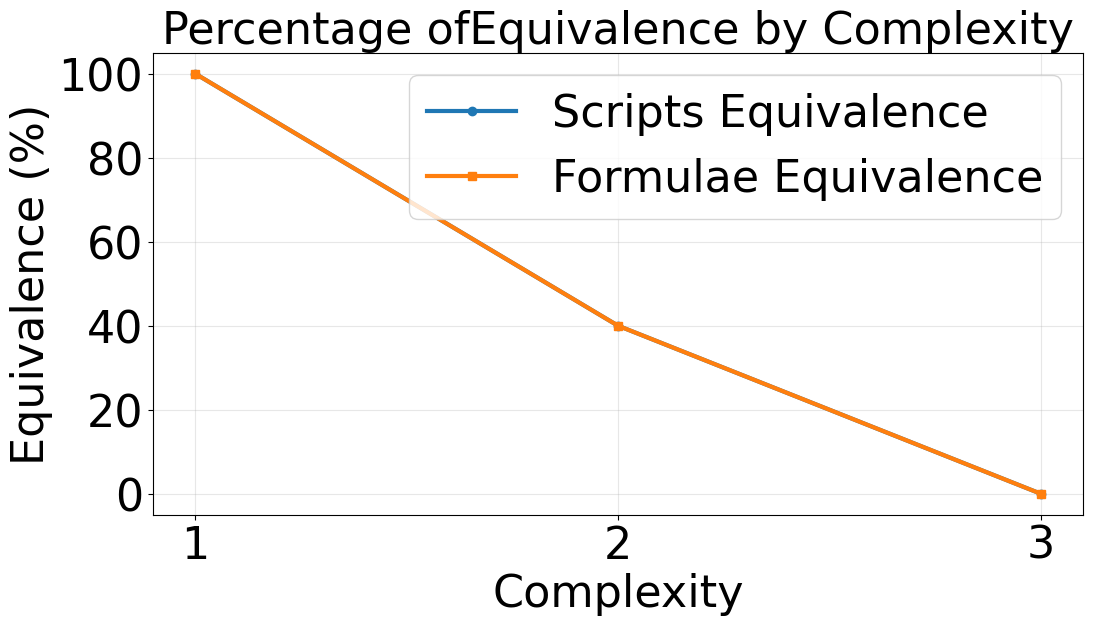

In [4]:
# Compare Python implementations for equivalence
df['equivalence_python'] = df.apply(lambda row:
    100 if (row['eval_python_1'] != '*not found' and
            row['eval_python_1'] != '')
    else 0, axis=1)

# Compare Formula implementations for equivalence  
df['equivalence_formula'] = df.apply(lambda row:
    100 if (row['eval_formula_1'] != '*not found' and
            row['eval_formula_1'] != '')
    else 0, axis=1)

# Calculate and plot average equivalence by complexity
equiv_by_complexity = df.groupby('complexity')[['equivalence_python', 'equivalence_formula']].mean()

# Print tabulated results
print("\nEquivalence Results by Complexity Level:")
print("----------------------------------------")
print("         | Complexity 1 | Complexity 2 | Complexity 3")
print("----------------------------------------")
print(f"Scripts  | {equiv_by_complexity['equivalence_python'][1]:^11.1f} | {equiv_by_complexity['equivalence_python'][2]:^11.1f} | {equiv_by_complexity['equivalence_python'][3]:^11.1f}")
print(f"Formulae | {equiv_by_complexity['equivalence_formula'][1]:^11.1f} | {equiv_by_complexity['equivalence_formula'][2]:^11.1f} | {equiv_by_complexity['equivalence_formula'][3]:^11.1f}")
print("----------------------------------------")

plt.figure(figsize=(12, 6))
plt.rcParams.update({'font.size': 32})  # Double the default font size
x = equiv_by_complexity.index
# Filter for only complexity levels 1-3
mask = (x >= 1) & (x <= 3)
x = x[mask]
plt.plot(x, equiv_by_complexity['equivalence_python'][mask], 'o-', label='Scripts Equivalence', linewidth=3)
plt.plot(x, equiv_by_complexity['equivalence_formula'][mask], 's-', label='Formulae Equivalence', linewidth=3)

plt.xlabel('Complexity', fontsize=32)
plt.ylabel('Equivalence (%)', fontsize=32)
plt.title('Percentage ofEquivalence by Complexity', fontsize=32)
plt.legend(fontsize=32)
plt.grid(True, alpha=0.3)

# Set x-axis to show only values 1,2,3
plt.xticks([1, 2, 3], fontsize=32)
plt.yticks(np.arange(0, 101, 20), fontsize=32)

plt.show()


### Evaluating accuracy


Accuracy Results by Complexity Level:
----------------------------------------
                  | Complexity 1 | Complexity 2 | Complexity 3
----------------------------------------
Python Scripts   |    100.0    |    20.0     |     0.0    
Single Script    |    100.0    |    20.0     |     0.0    
Formulae        |    100.0    |    20.0     |     0.0    
----------------------------------------


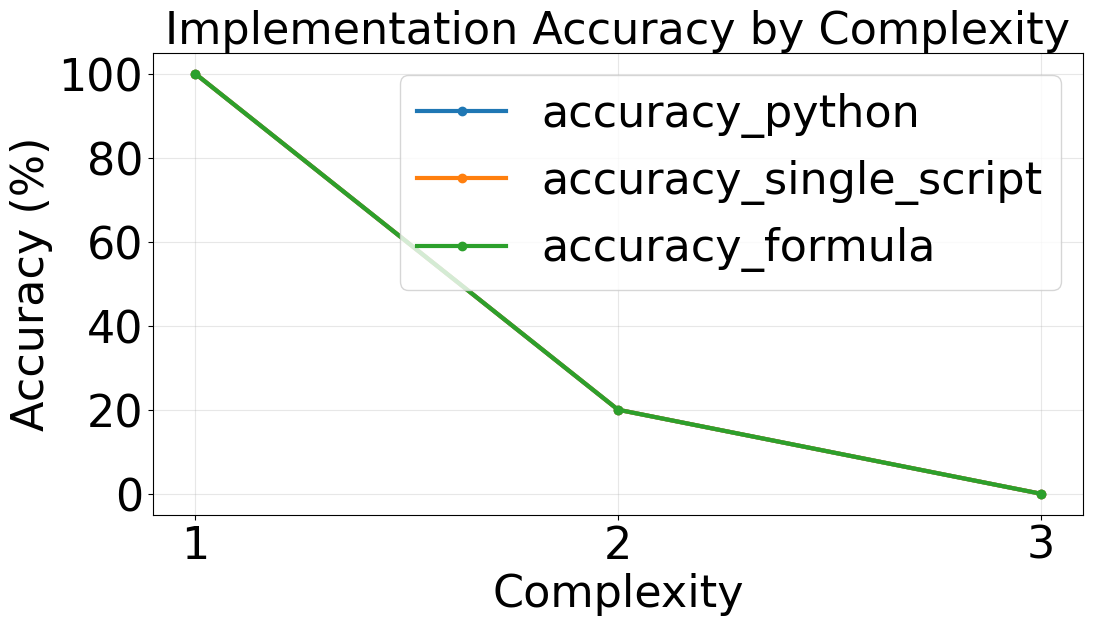

In [5]:
# Create accuracy columns for Python implementations
df['accuracy_python'] = df.apply(lambda row:
    True if (row['sequence'] == row['eval_python_1'] and 
            row['eval_python_1'] != '*not found')
    else False, axis=1)

# Compare sequence with single Python implementation
df['accuracy_single_script'] = df.apply(lambda row:
    True if (row['sequence'] == row['eval_single_script'] and
            row['eval_single_script'] != '*not found')
    else False, axis=1)

# Create accuracy column for Formula implementations 
df['accuracy_formula'] = df.apply(lambda row:
    True if (row['sequence'] == row['eval_formula_1'] and 
            row['eval_formula_1'] != '*not found')
    else False, axis=1)

# Calculate accuracy by complexity
accuracy_cols = ['accuracy_python', 'accuracy_single_script', 'accuracy_formula']
accuracy_by_complexity = df[df['complexity'].between(1,3)].groupby('complexity')[accuracy_cols].mean() * 100

# Print tabulated results
print("\nAccuracy Results by Complexity Level:")
print("----------------------------------------")
print("                  | Complexity 1 | Complexity 2 | Complexity 3")
print("----------------------------------------")
print(f"Python Scripts   | {accuracy_by_complexity['accuracy_python'][1]:^11.1f} | {accuracy_by_complexity['accuracy_python'][2]:^11.1f} | {accuracy_by_complexity['accuracy_python'][3]:^11.1f}")
print(f"Single Script    | {accuracy_by_complexity['accuracy_single_script'][1]:^11.1f} | {accuracy_by_complexity['accuracy_single_script'][2]:^11.1f} | {accuracy_by_complexity['accuracy_single_script'][3]:^11.1f}")
print(f"Formulae        | {accuracy_by_complexity['accuracy_formula'][1]:^11.1f} | {accuracy_by_complexity['accuracy_formula'][2]:^11.1f} | {accuracy_by_complexity['accuracy_formula'][3]:^11.1f}")
print("----------------------------------------")

# Plot accuracy results
plt.figure(figsize=(12, 6))
plt.rcParams.update({'font.size': 32})  # Double the default font size

for col in accuracy_cols:
    plt.plot(accuracy_by_complexity.index, accuracy_by_complexity[col], 'o-', linewidth=3, label=col)

plt.xlabel('Complexity', fontsize=32)
plt.ylabel('Accuracy (%)', fontsize=32)
plt.title('Implementation Accuracy by Complexity', fontsize=32)
plt.legend(fontsize=32)
plt.grid(True, alpha=0.3)
# Set x-axis to show only values 1,2,3
plt.xticks([1, 2, 3], fontsize=32)
plt.yticks(np.arange(0, 101, 20), fontsize=32)
plt.show()


### types between the total


Python Solution Types Distribution by Complexity (Total Numbers)
-----------------------------------------------------------------
Complexity | Known sequence | Pure math | Not found
-----------------------------------------------------------------
    1     |       0       |    30     |     0    
    2     |       4       |     8     |    18    
    3     |       0       |     0     |    30    
-----------------------------------------------------------------

Formula Solution Types Distribution by Complexity (Total Numbers)
-----------------------------------------------------------------
Complexity | Known sequence | Pure math | Not found
-----------------------------------------------------------------
    1     |       0       |    30     |     0    
    2     |       4       |     8     |    18    
    3     |       0       |     0     |    30    
-----------------------------------------------------------------


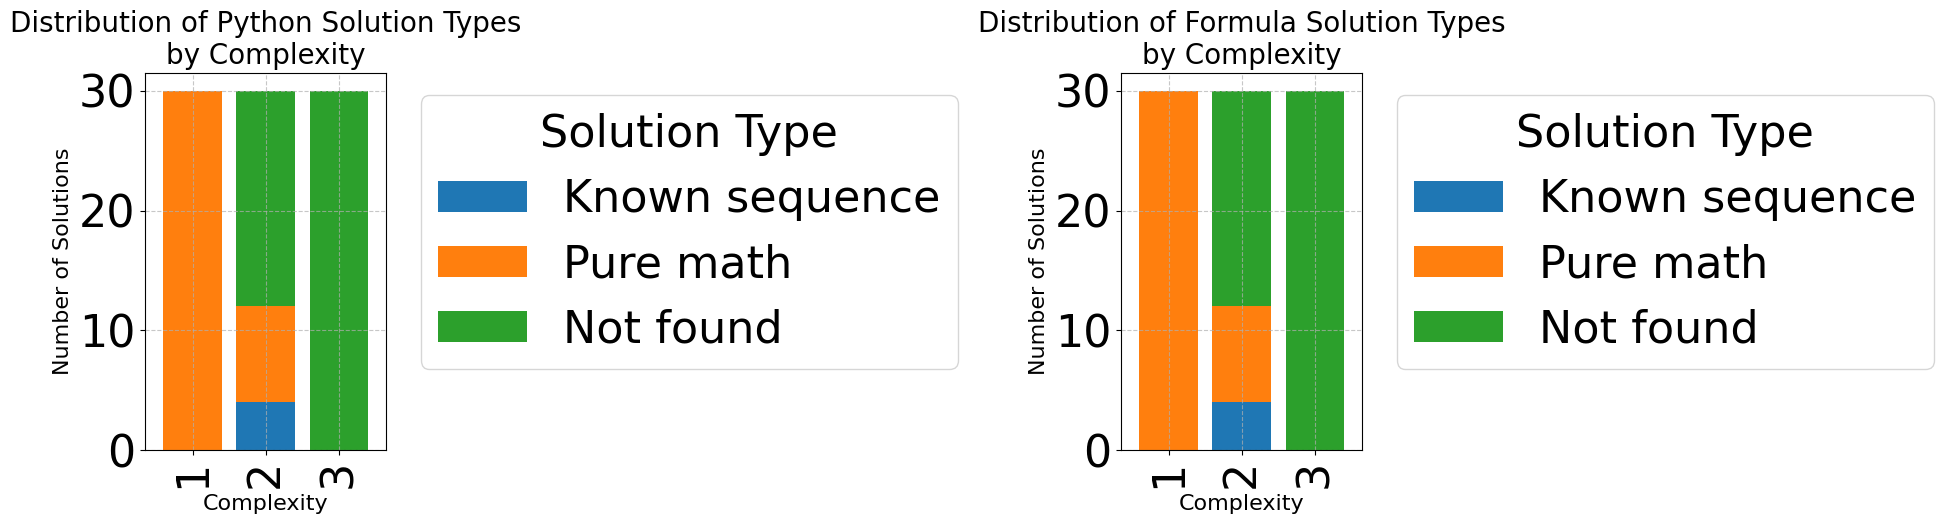

In [7]:
# Get value counts for Python types by complexity
python_types = df.groupby(['complexity', 'python_1_type']).size().unstack(fill_value=0)

# Get value counts for Formula types by complexity 
formula_types = df.groupby(['complexity', 'formula_1_type']).size().unstack(fill_value=0)

# Reorder columns to ensure matching colors for specific categories
python_cols = ['Known sequence', 'Pure math', 'Not found']
formula_cols = ['Known sequence', 'Pure math', 'Not found']

python_types = python_types[python_cols]
formula_types = formula_types[formula_cols]

# Print Python types distribution table
print("\nPython Solution Types Distribution by Complexity (Total Numbers)")
print("-" * 65)
print("Complexity | Known sequence | Pure math | Not found")
print("-" * 65)
for idx in python_types.index:
    print(f"{idx:^9d} | {python_types.loc[idx, 'Known sequence']:^13d} | {python_types.loc[idx, 'Pure math']:^9d} | {python_types.loc[idx, 'Not found']:^9d}")
print("-" * 65)

# Print Formula types distribution table
print("\nFormula Solution Types Distribution by Complexity (Total Numbers)")
print("-" * 65)
print("Complexity | Known sequence | Pure math | Not found")
print("-" * 65)
for idx in formula_types.index:
    print(f"{idx:^9d} | {formula_types.loc[idx, 'Known sequence']:^13d} | {formula_types.loc[idx, 'Pure math']:^9d} | {formula_types.loc[idx, 'Not found']:^9d}")
print("-" * 65)

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot Python types
python_types.plot(kind='bar', stacked=True, width=0.8, ax=ax1)
ax1.set_title('Distribution of Python Solution Types\nby Complexity', fontsize=20)
ax1.set_xlabel('Complexity', fontsize=16)
ax1.set_ylabel('Number of Solutions', fontsize=16)
ax1.legend(title='Solution Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot Formula types
formula_types.plot(kind='bar', stacked=True, width=0.8, ax=ax2)
ax2.set_title('Distribution of Formula Solution Types\nby Complexity', fontsize=20)
ax2.set_xlabel('Complexity', fontsize=16)
ax2.set_ylabel('Number of Solutions', fontsize=16)
ax2.legend(title='Solution Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [9]:
df.columns

Index(['sequence', 'complexity', 'single_formula', 'eval_single_formula',
       'single_formula_type', 'single_python', 'eval_single_script',
       'single_python_type', 'multiple_python', 'python_1', 'eval_python_1',
       'python_1_type', 'multiple_formula', 'formula_1', 'eval_formula_1',
       'formula_1_type', 'equivalence_python', 'equivalence_formula',
       'accuracy_python', 'accuracy_single_script', 'accuracy_formula'],
      dtype='object')

### types between the correct


Python Solution Types Distribution by Complexity (Accurate Cases Only - Total Numbers)
-----------------------------------------------------------------
Complexity | Known sequence | Pure math | Not found
-----------------------------------------------------------------
    1     |       0       |    30     |     0    
    2     |       3       |     3     |     0    
    3     |       0       |     0     |     0    
-----------------------------------------------------------------

Formula Solution Types Distribution by Complexity (Accurate Cases Only - Total Numbers)
-----------------------------------------------------------------
Complexity | Known sequence | Pure math | Not found
-----------------------------------------------------------------
    1     |       0       |    30     |     0    
    2     |       3       |     3     |     0    
    3     |       0       |     0     |     0    
-----------------------------------------------------------------


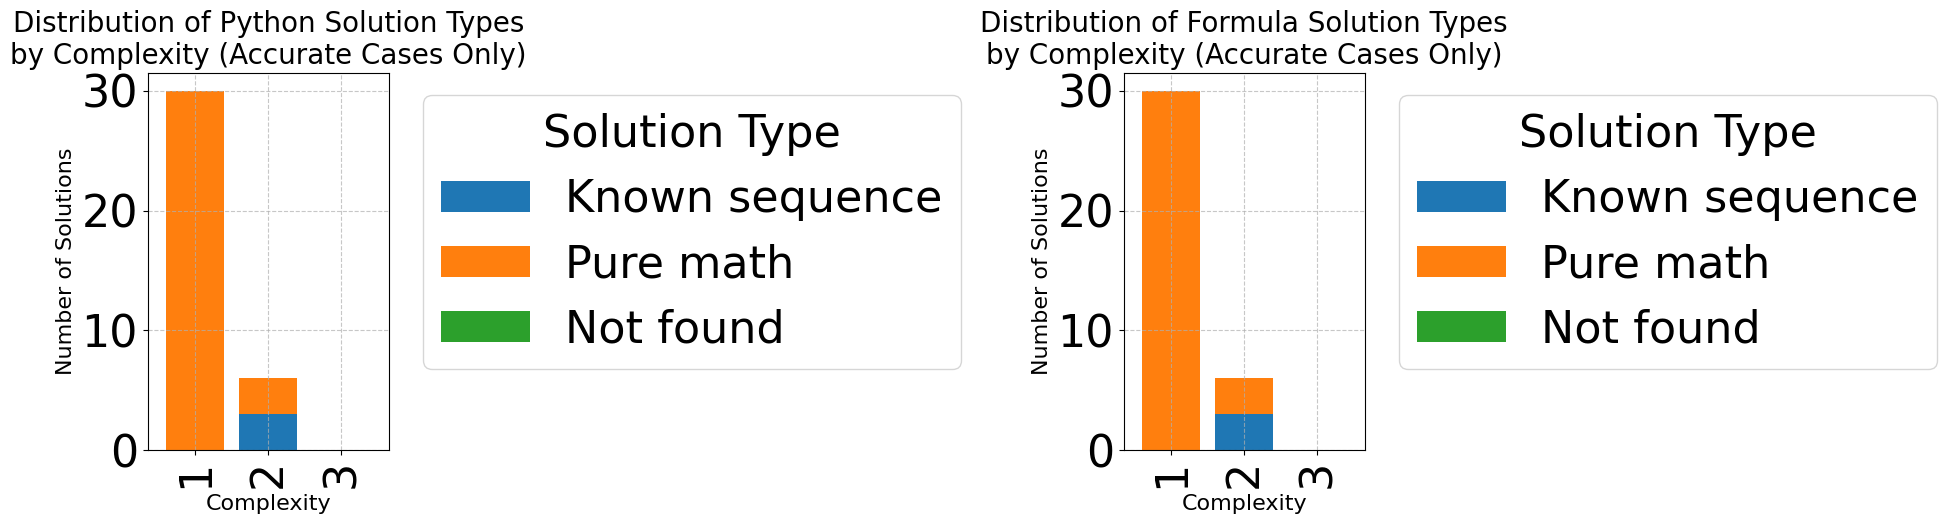

In [10]:
# Filter for accurate cases only (considering both python and formula)
accurate_df = df[df['accuracy_python'] & df['accuracy_formula']]

# Check if there are any accurate cases
if len(accurate_df) > 0:
    # Get value counts for Python types by complexity (accurate cases only)
    accurate_python_types = accurate_df.groupby(['complexity', 'python_1_type']).size().unstack(fill_value=0)

    # Get value counts for Formula types by complexity (accurate cases only) 
    accurate_formula_types = accurate_df.groupby(['complexity', 'formula_1_type']).size().unstack(fill_value=0)

    # Add complexity 3 if not present
    if 3 not in accurate_python_types.index:
        accurate_python_types.loc[3] = 0
        accurate_formula_types.loc[3] = 0
    
    # Sort index to ensure complexity 3 appears in correct position
    accurate_python_types = accurate_python_types.sort_index()
    accurate_formula_types = accurate_formula_types.sort_index()

    # Define all columns we want to show
    python_cols = ['Known sequence', 'Pure math', 'Not found']  # Removed 'Print' from default columns
    formula_cols = ['Known sequence', 'Pure math', 'Not found']

    # Add missing columns with zeros if they don't exist
    for col in python_cols:
        if col not in accurate_python_types.columns:
            accurate_python_types[col] = 0
    
    for col in formula_cols:
        if col not in accurate_formula_types.columns:
            accurate_formula_types[col] = 0

    # Add 'Print' column only if it exists in the data
    if 'Print' in accurate_python_types.columns:
        python_cols.append('Print')

    # Ensure columns are in desired order
    accurate_python_types = accurate_python_types[python_cols]
    accurate_formula_types = accurate_formula_types[formula_cols]

    # Print distribution tables for accurate cases
    print("\nPython Solution Types Distribution by Complexity (Accurate Cases Only - Total Numbers)")
    header = "Complexity | Known sequence | Pure math | Not found"
    separator = "-" * 65
    
    if 'Print' in python_cols:
        header += " | Print"
        separator = "-" * 80
    
    print(separator)
    print(header)
    print(separator)
    
    for idx in accurate_python_types.index:
        row = f"{idx:^9d} | {accurate_python_types.loc[idx, 'Known sequence']:^13d} | {accurate_python_types.loc[idx, 'Pure math']:^9d} | {accurate_python_types.loc[idx, 'Not found']:^9d}"
        if 'Print' in python_cols:
            row += f" | {accurate_python_types.loc[idx, 'Print']:^5d}"
        print(row)
    print(separator)

    print("\nFormula Solution Types Distribution by Complexity (Accurate Cases Only - Total Numbers)")
    print("-" * 65)
    print("Complexity | Known sequence | Pure math | Not found")
    print("-" * 65)
    for idx in accurate_formula_types.index:
        print(f"{idx:^9d} | {accurate_formula_types.loc[idx, 'Known sequence']:^13d} | {accurate_formula_types.loc[idx, 'Pure math']:^9d} | {accurate_formula_types.loc[idx, 'Not found']:^9d}")
    print("-" * 65)

    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    # Plot Python types (accurate cases)
    accurate_python_types.plot(kind='bar', stacked=True, width=0.8, ax=ax1)
    ax1.set_title('Distribution of Python Solution Types\nby Complexity (Accurate Cases Only)', fontsize=20)
    ax1.set_xlabel('Complexity', fontsize=16)
    ax1.set_ylabel('Number of Solutions', fontsize=16)
    ax1.legend(title='Solution Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Plot Formula types (accurate cases)
    accurate_formula_types.plot(kind='bar', stacked=True, width=0.8, ax=ax2)
    ax2.set_title('Distribution of Formula Solution Types\nby Complexity (Accurate Cases Only)', fontsize=20)
    ax2.set_xlabel('Complexity', fontsize=16)
    ax2.set_ylabel('Number of Solutions', fontsize=16)
    ax2.legend(title='Solution Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("No accurate cases found in the dataset")
